# TALLER 2 ANALISIS NUMÉRICO

## EJERCICIOS DE APLICACIÓN

**Docente:** Leidy Yoana Medina Torres

---

### Integrantes del equipo de trabajo

- *DANIEL MORALES*
- *JUAN MANUEL GOMEZ*

---

In [1]:
# Imports

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import sel as s
import modelos as ml
import Ceros as c
import ecuaciones as ec
import SerieT as st

# Ejercicio 1 — Crecimiento alométrico de la Platija

El crecimiento alométrico es el estudio del tamaño relativo de diferentes partes de un organismo como consecuencia del crecimiento. Se realizó un experimento relacionando el peso de la platija (especie de pez) $w(t)$ con respecto a su longitud $L(t)$.

| Longitud (cm) | Peso (g) | Longitud (cm) | Peso (g) |
|:---:|:---:|:---:|:---:|
| 23.5 | 124 | 37.5 | 455 |
| 24.5 | 146 | 38.5 | 500 |
| 25.5 | 155 | 39.5 | 538 |
| 26.5 | 174 | 40.5 | 574 |
| 27.5 | 190 | 41.5 | 623 |
| 28.5 | 213 | 42.5 | 674 |
| 29.5 | 236 | 43.5 | 724 |
| 30.5 | 259 | 44.5 | 808 |
| 31.5 | 284 | 45.5 | 812 |
| 32.5 | 308 | 46.5 | 909 |
| 33.5 | 332 | 47.5 | 1039 |
| 34.5 | 363 | 48.5 | 1124 |
| 35.5 | 391 | 49.5 | 1163 |
| 36.5 | 419 |  |  |

**a)** Hacer un gráfico de los datos longitud versus peso de la Platija.

**b)** Construir un polinomio que pase por cada uno del conjunto de datos y aproxime el peso de una platija americana cuya longitud máxima registrada es de 60 cm. Concluya si el modelo construido es coherente, si representa la tendencia de la información proporcionada.

**c)** Construya un modelo de ajuste que represente la tendencia de los datos proporcionados y permita aproximar el peso de una platija americana cuya longitud máxima registrada es de 60 cm. Concluya si el modelo es coherente, pertinente y si su construcción es adecuada con base únicamente en los datos suministrados.

**d)** Hacer las gráficas de cada ítem de manera separada.

In [2]:
L_data = np.array([23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
                   33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42.5,
                   43.5, 44.5, 45.5, 46.5, 47.5, 48.5, 49.5])

w_data = np.array([124, 146, 155, 174, 190, 213, 236, 259, 284, 308,
                   332, 363, 391, 419, 455, 500, 538, 574, 623, 674,
                   724, 808, 812, 909, 1039, 1124, 1163])

### a) Gráfico de los datos longitud vs peso


In [3]:
    plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.title('Datos longitud vs peso - Platija americana')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

IndentationError: unexpected indent (261753413.py, line 1)

### b) Polinomio interpolante que pasa por todos los puntos

In [ ]:
x = sp.symbols('x')

P_lagrange = ml.lagrange(L_data, w_data)
P_func = sp.lambdify(x, P_lagrange)

w_60_poli = float(P_func(60))
print(f"Aproximacion del peso para L = 60 cm: w(60) = {w_60_poli}")

# Justificacion: el polinomio de grado 26 pasa exactamente por los 27 puntos del
# intervalo [23.5, 49.5] cm, pero al extrapolar a L = 60 cm produce un valor sin
# sentido (fenomeno de Runge). El modelo no es coherente fuera del rango.

Aproximacion del peso para L = 60 cm: w(60) = -4215794534925375.0


### c) Modelo de ajuste por mínimos cuadrados

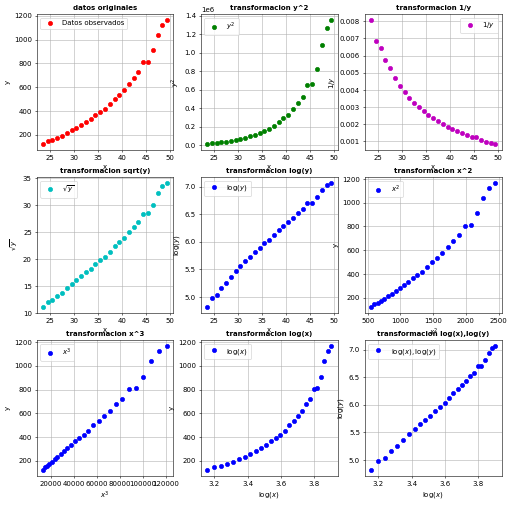

In [ ]:
# Visualizacion de las escalas para escoger la transformacion mas optima
ml.escalas(L_data, w_data)

In [ ]:
# Coeficientes de determinacion para los modelos
R_lineal  = ml.coeficiente_determinacion(L_data, w_data)
R_x3      = ml.coeficiente_determinacion(L_data**3, w_data)
R_loglog  = ml.coeficiente_determinacion(np.log(L_data), np.log(w_data))

print(f"R^2 (L, w)              : {R_lineal}")
print(f"R^2 (L^3, w)            : {R_x3}")
print(f"R^2 (log(L), log(w))    : {R_loglog}")

R^2 (L, w)              : 0.9362218067143112
R^2 (L^3, w)            : 0.9918775506182635
R^2 (log(L), log(w))    : 0.9961836639396179


In [ ]:
# Ajuste de minimos cuadrados en escala log-log
b_coef, log_a = ml.minimos_cuadrados(np.log(L_data), np.log(w_data))
a_coef = np.exp(log_a)

w_modelo = lambda L: a_coef * L**b_coef

w_60_ajuste = w_modelo(60)
print(f"Modelo: w(L) = {a_coef:.6f} * L^{b_coef:.6f}")
print(f"Aproximacion para L = 60 cm: w(60) = {w_60_ajuste:.4f} g")

# Justificacion: el modelo w = a*L^b con b = 2.95 es coherente en peso-longitud.
# Predice w(60) = 1910 g, este valor es adecuado en comparacion al rango de datos iniciales.

Modelo: w(L) = 0.010737 * L^2.952605
Aproximacion para L = 60 cm: w(60) = 1910.0935 g


### d) Gráficas de cada ítem por separado

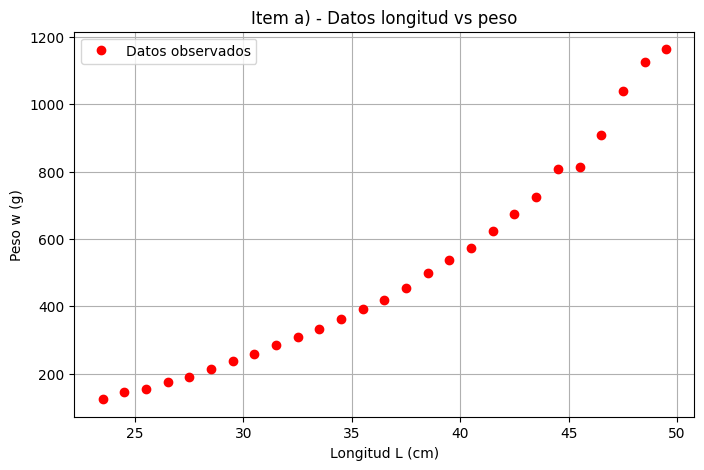

In [ ]:
# Grafica del item a)
plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.title('Item a) - Datos longitud vs peso')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

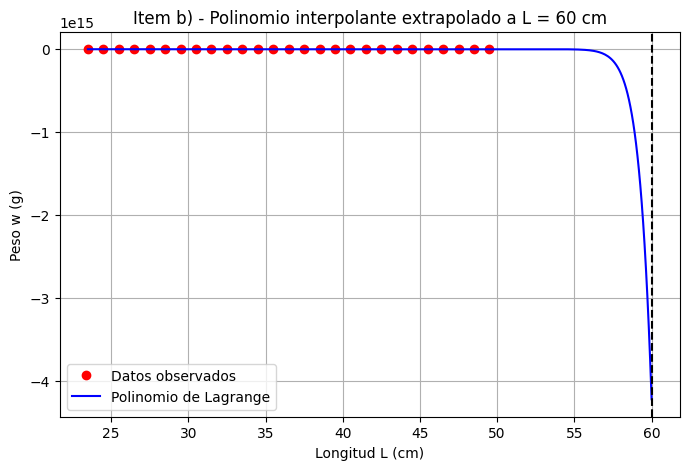

In [ ]:
# Grafica del item b)
L_plot_b = np.linspace(L_data.min(), 60, 400)
y_plot_b = np.array([float(P_func(Li)) for Li in L_plot_b])

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_b, y_plot_b, 'b-', label='Polinomio de Lagrange')
plt.axvline(60, color='k', linestyle='--')
plt.title('Item b) - Polinomio interpolante extrapolado a L = 60 cm')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

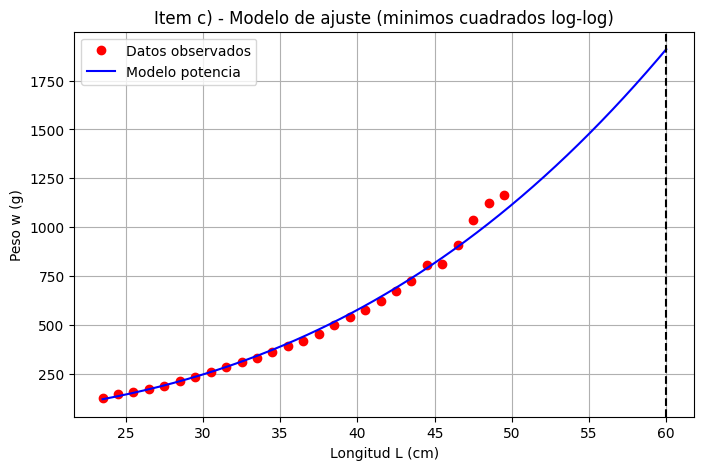

In [ ]:
# Grafica del item c)
L_plot_c = np.linspace(L_data.min(), 60, 200)

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_c, w_modelo(L_plot_c), 'b-', label='Modelo potencia')
plt.axvline(60, color='k', linestyle='--')
plt.title('Item c) - Modelo de ajuste (minimos cuadrados log-log)')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

# Ejercicio 2 — Salto vertical de una bailarina de ballet

Un salto vertical realizado por una bailarina de ballet está descrito por la ecuación diferencial

$$m\, v' = -m\, g$$

Aquí $m$ es la masa de la bailarina de ballet, $g = 32.2\ \text{pies}/\text{s}^2$ es la constante gravitacional y $v' = \dfrac{dv}{dt}$, $v = \dfrac{dy}{dt}$, donde $y$ es la distancia vertical medida desde el piso hasta el centro de gravedad de la bailarina.

Se considera que en $t = 0$ la bailarina despega con velocidad inicial

$$v_0 = \frac{g\, T}{2},$$

siendo $T$ el tiempo total de vuelo.

**a)** Resolver numéricamente la ecuación diferencial utilizando el método de Euler y el método de Runge-Kutta de cuarto orden (RK4) para $T = 1/3$ segundos.

**b)** Comparar la altura máxima obtenida numéricamente con el valor exacto

$$H = \tfrac{1}{8}\, g\, T^{2} \approx 5.4\ \text{pulgadas}.$$

**c)** Analizar el error cometido por cada método para diferentes tamaños de paso $\Delta t$.

**d)** Realizar la gráfica del tiempo versus la altura, y el tiempo versus la velocidad e interprete.

## Solucion Ejercicio 2

### a) Solucion numerica con Euler y Rk4

In [4]:
# Parametros del problema
g  = 32.2
T  = 1 / 3
v0 = g * T / 2


def salto(t, u):
    y = u[0]
    v = u[1]
    f1 = v
    f2 = -9.8
    return np.array([f1, f2])

u0 = np.array([0.0, v0])
h  = T / 10

t_e, sol_e = ec.Euler(salto, 0, T, h, u0)
t_r, sol_r = ec.Rk4  (salto, 0, T, h, u0)

sol_e = np.array(sol_e)
sol_r = np.array(sol_r)
y_e, v_e = sol_e[:, 0], sol_e[:, 1]
y_r, v_r = sol_r[:, 0], sol_r[:, 1]

print(f"Altura maxima Euler = {y_e.max():.6f}")
print(f"Altura maxima Rk4   = {y_r.max():.6f}")

Altura maxima Euler = 1.298889
Altura maxima Rk4   = 1.279531


### b) Comparacion con la altura maxima exacta

In [8]:
H_exacto = g * T**2 / 8
H_e = y_e.max()
H_r = y_r.max()

print(f"H exacto = {H_exacto:.6f} ({H_exacto*12:.4f} pulgadas)")
print(f"H Euler  = {H_e:.6f}   error = {abs(H_e - H_exacto):.4e}")
print(f"H Rk4    = {H_r:.6f}   error = {abs(H_r - H_exacto):.4e}")

# justificacion: H = 5.4 pulgadas. Rk4 se aproxima mejor que Euler con el
# mismo h al ser un metodo de orden superior; Euler sobreestima la
# altura maxima.

H exacto = 0.447222 (5.3667 pulgadas)
H Euler  = 1.298889   error = 8.5167e-01
H Rk4    = 1.279531   error = 8.3231e-01


### c) Analisis del error para diferentes tamaños de paso

In [10]:
print(f"{'n':>5} | {'h':>10} | {'Err Euler':>14} | {'Err Rk4':>14}")
print("-" * 55)

pasos = [5, 10, 20, 50, 100, 200]

for n in pasos:
    h_i = T / n
    _, se = ec.Euler(salto, 0, T, h_i, u0)
    _, sr = ec.Rk4  (salto, 0, T, h_i, u0)
    err_e = abs(np.array(se)[:, 0].max() - H_exacto)
    err_r = abs(np.array(sr)[:, 0].max() - H_exacto)
    print(f"{n:>5} | {h_i:>10.6f} | {err_e:>14.4e} | {err_r:>14.4e}")

# justificacion: el error de Euler se reduce a la mitad al duplicar n,
# confirmando que es O(h). Rk4 entrega menor error que Euler con el mismo h
# al ser un metodo de orden superior.

    n |          h |      Err Euler |        Err Rk4
-------------------------------------------------------
    5 |   0.066667 |     9.0611e-01 |     8.6498e-01
   10 |   0.033333 |     8.5167e-01 |     8.3231e-01
   20 |   0.016667 |     8.2444e-01 |     8.1507e-01
   50 |   0.006667 |     8.0811e-01 |     8.0443e-01
  100 |   0.003333 |     8.0267e-01 |     8.0084e-01
  200 |   0.001667 |     7.9994e-01 |     7.9903e-01


### d) Graficas tiempo vs altura y tiempo vs velocidad

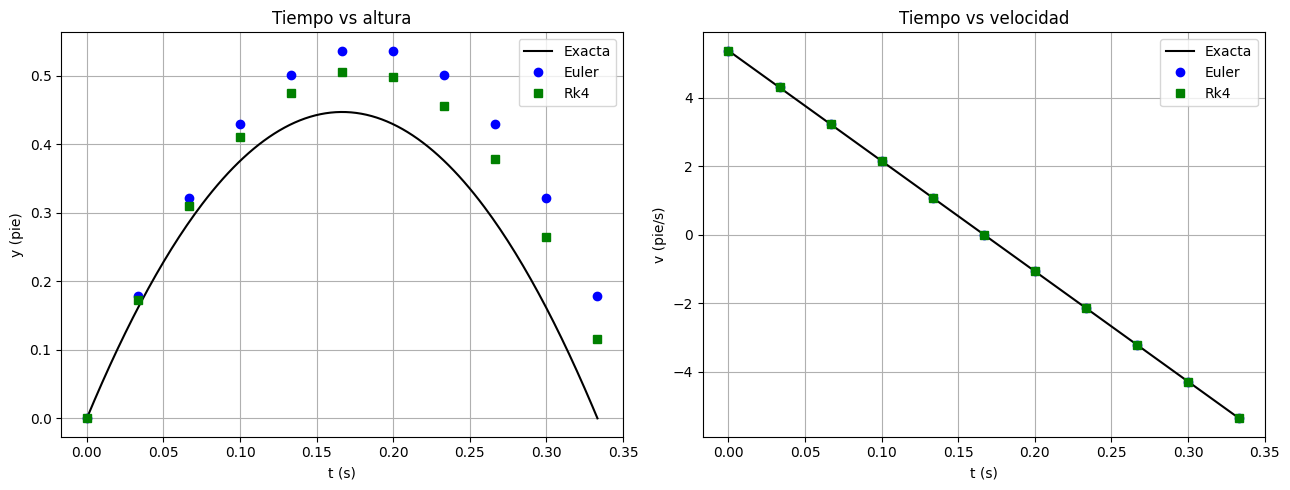

In [ ]:
t_exact = np.linspace(0, T, 200)
y_exact = v0*t_exact - 0.5*g*t_exact**2
v_exact = v0 - g*t_exact

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t_exact, y_exact, 'k-', label='Exacta')
axes[0].plot(t_e, y_e, 'ob', label='Euler')
axes[0].plot(t_r, y_r, 'sg', label='Rk4')
axes[0].set_title('Tiempo vs altura')
axes[0].set_xlabel('t (s)')
axes[0].set_ylabel('y (pie)')
axes[0].grid(True); axes[0].legend()

axes[1].plot(t_exact, v_exact, 'k-', label='Exacta')
axes[1].plot(t_e, v_e, 'ob', label='Euler')
axes[1].plot(t_r, v_r, 'sg', label='Rk4')
axes[1].set_title('Tiempo vs velocidad')
axes[1].set_xlabel('t (s)')
axes[1].set_ylabel('v (pie/s)')
axes[1].grid(True); axes[1].legend()

plt.tight_layout()
plt.show()

# justificacion: la altura es una parabola con maximo en t = T/2; la velocidad
# es lineal, vale 0 en el apice y -v0 al aterrizar. Rk4 coincide con la curva
# exacta; Euler se desvia por su error O(h).

# Ejercicio 3 — Crecimiento alométrico del cangrejo violinista

El cangrejo violinista es un pequeño crustáceo, famoso porque los machos poseen una pinza desproporcionadamente grande, usada para cortejo y defensa, que recuerda a un violín.

El crecimiento alométrico es el estudio de los tamaños relativos de las diferentes partes de un organismo como consecuencia del crecimiento. Uno de los modelos más simples de alometría es aquel en el que se supone que las razones de crecimiento relativo de los dos componentes $y(t)$ y $x(t)$ satisfacen:

$$\frac{dy}{dx} = a\frac{y}{x}$$

donde $a$ es una constante. La tabla muestra los resultados de un experimento en el cual se obtuvieron los pesos relativos del cuerpo y la tenaza del cangrejo violinista. El peso del cuerpo es el peso total del cangrejo restando el peso de la tenaza. Aunque es posible describir este conjunto de datos en una simple ecuación alométrica, resulta un modelo mejor si se conjuntan dos ecuaciones alométricas.

| Peso del cuerpo (mg) | Peso de la tenaza (mg) | Peso del cuerpo (mg) | Peso de la tenaza (mg) |
|:---:|:---:|:---:|:---:| 
| 57.6 | 5.3 | 680.6 | 271.6 |
| 80.3 | 9.0 | 743.3 | 319.2 |
| 109.2 | 13.7 | 872.4 | 417.6 |
| 156.1 | 25.1 | 983.1 | 460.8 |
| 199.7 | 38.3 | 1079.9 | 537.0 |
| 283.3 | 52.5 | 1165.5 | 593.8 |
| 270.0 | 59.0 | 1211.7 | 616.8 |
| 300.2 | 78.1 | 1291.3 | 670.0 |
| 355.2 | 104.5 | 1363.2 | 699.3 |
| 420.1 | 135.0 | 1449.1 | 777.8 |
| 470.1 | 164.9 | 1807.9 | 1009.1 |
| 535.7 | 195.6 | 2235.0 | 1380.0 |
| 617.9 | 243.0 |  |  |

**a)** Construya un polinomio que pase por todos los puntos. Se cree que la iniciación de la madurez sexual de un cangrejo violinista se presenta cuando su peso total excede alrededor de 1.1 g. ¿Es consistente con su modelo? Haga una gráfica de los datos versus el modelo construido.

**b)** Construya un modelo no lineal en dos fases, uno para el grupo joven y otro para el grupo maduro. Haga una gráfica del modelo versus los datos.

**c)** ¿Qué significa que el crecimiento sea **alométrico**? Diferéncielo del crecimiento **isométrico**.

**d)** Compare los exponentes alométricos obtenidos para la fase joven y la fase madura. ¿Qué diferencia observa y qué significado biológico podría tener?

**e)** Según su modelo de dos fases, ¿en cuál etapa crece proporcionalmente más la tenaza con respecto al cuerpo? Justifique.

**f)** Utilizando el modelo de dos fases, estime el peso de la tenaza para un cangrejo cuyo cuerpo pesa 500 mg y para otro cuyo cuerpo pesa 2000 mg. ¿En qué fase se encuentra cada uno?

**g)** Si se desea predecir el peso de la tenaza para un cangrejo con peso corporal de 3000 mg, ¿cuál de los dos modelos (polinomio exacto o dos fases) es más confiable? ¿Por qué?

## Solucion Ejercicio 3 

In [11]:
x_data = np.array([57.6, 80.3, 109.2, 156.1, 199.7, 283.3, 270.0, 300.2, 355.2, 420.1,
                   470.1, 535.7, 617.9, 680.6, 743.3, 872.4, 983.1, 1079.9, 1165.5,
                   1211.7, 1291.3, 1363.2, 1449.1, 1807.9, 2235.0])
y_data = np.array([5.3, 9.0, 13.7, 25.1, 38.3, 52.5, 59.0, 78.1, 104.5, 135.0,
                   164.9, 195.6, 243.0, 271.6, 319.2, 417.6, 460.8, 537.0, 593.8,
                   616.8, 670.0, 699.3, 777.8, 1009.1, 1380.0])


T_data = x_data + y_data

### a) Polinomio de interpolacion y umbral de madurez

La solucion de al funcion: 871.1411661624909
La cantidad de iteraciones necesarias fueron 21
Cuerpo en la madurez:  x* = 871.1412 mg
Tenaza en la madurez:  y* = 228.8661 mg
Total en la madurez:   T* = 1100.0072 mg


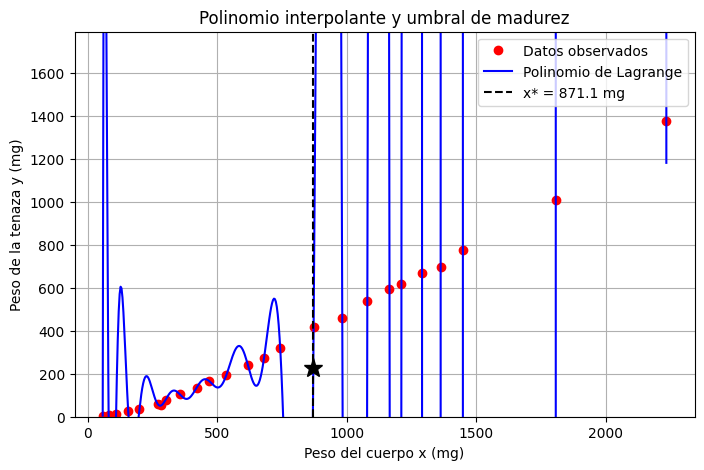

In [ ]:
x_sym = sp.symbols('x')

P_lagrange = ml.lagrange(x_data, y_data)
P_func = sp.lambdify(x_sym, P_lagrange)

f_madurez = lambda xv: xv + float(P_func(xv)) - 1100.0
x_madurez = c.Biseccion(f_madurez, 743.3, 872.4, 1e-4)
y_madurez = float(P_func(x_madurez))

print(f"Cuerpo en la madurez:  x* = {x_madurez:.4f} mg")
print(f"Tenaza en la madurez:  y* = {y_madurez:.4f} mg")
print(f"Total en la madurez:   T* = {x_madurez + y_madurez:.4f} mg")

x_plot = np.linspace(x_data.min(), x_data.max(), 600)
y_plot = np.array([float(P_func(xv)) for xv in x_plot])

plt.figure(figsize=(8, 5))
plt.plot(x_data, y_data, 'or', label='Datos observados')
plt.plot(x_plot, y_plot, 'b-', label='Polinomio de Lagrange')
plt.axvline(x_madurez, color='k', linestyle='--', label=f'x* = {x_madurez:.1f} mg')
plt.plot(x_madurez, y_madurez, 'k*', markersize=14)
plt.ylim(0, 1.3 * y_data.max())
plt.title('Polinomio interpolante y umbral de madurez')
plt.xlabel('Peso del cuerpo x (mg)')
plt.ylabel('Peso de la tenaza y (mg)')
plt.grid(True)
plt.legend()
plt.show()

# justificacion: x* = 871.14 mg con T* = 1100 mg es consistente con los datos,
# ya que la transicion queda entre el utlimo dato joven (x=743.3, T=1062.5) y
# el primer dato maduro (x=872.4, T=1290). El polinomio sufre fenomeno de Runge y
# entrega valores absurdos al extrapolar, por lo que no es un modelo predictivo.

### b) Modelo no lineal en dos fases

Modelo joven : y = 0.006935 * x^1.625746   (R^2 = 0.996128)
Modelo maduro: y = 0.072752 * x^1.274184   (R^2 = 0.997207)


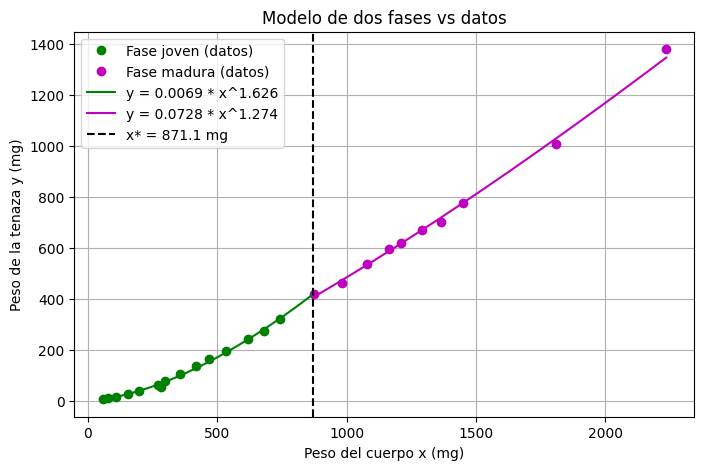

In [ ]:
# separacion de los datos
cangrejo_joven  = T_data < 1100
cangrejo_maduro = T_data > 1100
x_joven,  y_joven  = x_data[cangrejo_joven],  y_data[cangrejo_joven]
x_maduro, y_maduro = x_data[cangrejo_maduro], y_data[cangrejo_maduro]

# Minimos cuadrados en escala log-log
a_joven,  log_c_joven  = ml.minimos_cuadrados(np.log(x_joven),  np.log(y_joven))
a_maduro, log_c_maduro = ml.minimos_cuadrados(np.log(x_maduro), np.log(y_maduro))
c_joven  = np.exp(log_c_joven)
c_maduro = np.exp(log_c_maduro)
R2_joven  = ml.coeficiente_determinacion(np.log(x_joven),  np.log(y_joven))
R2_maduro = ml.coeficiente_determinacion(np.log(x_maduro), np.log(y_maduro))

modelo_joven  = lambda x: c_joven  * x**a_joven
modelo_maduro = lambda x: c_maduro * x**a_maduro

print(f"Modelo joven : y = {c_joven:.6f} * x^{a_joven:.6f}   (R^2 = {R2_joven:.6f})")
print(f"Modelo maduro: y = {c_maduro:.6f} * x^{a_maduro:.6f}   (R^2 = {R2_maduro:.6f})")

xj = np.linspace(x_joven.min(),  x_madurez,      200)
xm = np.linspace(x_madurez,      x_maduro.max(), 200)

plt.figure(figsize=(8, 5))
plt.plot(x_joven,  y_joven,  'og', label='Fase joven (datos)')
plt.plot(x_maduro, y_maduro, 'om', label='Fase madura (datos)')
plt.plot(xj, modelo_joven(xj),  'g-', label=f'y = {c_joven:.4f} * x^{a_joven:.3f}')
plt.plot(xm, modelo_maduro(xm), 'm-', label=f'y = {c_maduro:.4f} * x^{a_maduro:.3f}')
plt.axvline(x_madurez, color='k', linestyle='--', label=f'x* = {x_madurez:.1f} mg')
plt.title('Modelo de dos fases vs datos')
plt.xlabel('Peso del cuerpo x (mg)')
plt.ylabel('Peso de la tenaza y (mg)')
plt.grid(True)
plt.legend()
plt.show()

# justificacion: ambos R^2 (0.9961 y 0.9972) son altos, las curvas son suaves y
# monotonas, y el cambio de fase ocurre en x* = 871 mg.

### c) Crecimiento alometrico vs isometrico

In [16]:
# justificacion: en el modelo tenemos un crecimiento alometrico, ya que una parte gana y la otra
# pierde proporcion. Si ambas partes (cuerpo y teneza) crecieran de igual manera seria un crecimiento
# isometrico

### d) Comparacion de los exponentes alometricos por fase

In [ ]:
print(f"a_joven  = {a_joven:.4f}")
print(f"a_maduro = {a_maduro:.4f}")

# justificacion: a_joven > a_maduro > 1, ambas fases son alometricas positivas
# pero la alometria es mas intensa en la juventud. Biologicamente, el cangrejo
# genera un desarrollo mayor de la tenaza siendo joven para el cortejo y la
# defensa; alcanzada la madurez, ese crecimiento relativo se atenua al
# redirigirse energia a reproduccion y mantenimiento.

a_joven  = 1.6257
a_maduro = 1.2742


### e) Etapa de mayor crecimiento proporcional de la tenaza

In [ ]:
print(f"Fase joven : a = {a_joven:.4f}")
print(f"Fase madura: a = {a_maduro:.4f}")
print("--> La tenaza crece proporcionalmente mas en la fase joven.")

# justificacion: el exponente a mide cuanto crece la tenaza por cada poco que
# crece el cuerpo. Como a_joven > a_maduro, la respuesta es directa: la
# tenaza crece en mayor proporcion en la juventud que en la adultez.

Fase joven : a = 1.6257
Fase madura: a = 1.2742
--> La tenaza crece proporcionalmente mas en la fase joven.


### f) Estimacion de la tenaza para x = 500 mg y x = 2000 mg

In [18]:
def estimar_tenaza(x_cuerpo):
    if x_cuerpo < x_madurez:
        return "joven",  modelo_joven(x_cuerpo)
    return "madura", modelo_maduro(x_cuerpo)

pesos = [500.0, 2000.0]

for x_test in pesos:
    fase, y_pred = estimar_tenaza(x_test)
    print(f"Cuerpo x = {x_test:6.1f} mg -> fase {fase} | tenaza y = {y_pred:8.2f} mg")

# justificacion: con x* = 871 mg como frontera, 500 mg cae en la fase joven
# (tenaza ~169 mg) y 2000 mg en la madura (tenaza ~1169 mg). Cada peso se
# evalua en su propia curva: el modelo joven es solo para x < x* y el maduro
# para x >= x*.

Cuerpo x =  500.0 mg -> fase joven | tenaza y =   169.38 mg
Cuerpo x = 2000.0 mg -> fase madura | tenaza y =  1169.40 mg


### g) Prediccion para x = 3000 mg

In [ ]:
x_pred = 3000.0
y_pred_poli     = float(P_func(x_pred))
y_pred_dosfases = modelo_maduro(x_pred)

print(f"Polinomio de Lagrange = {y_pred_poli: .4e} mg")
print(f"Modelo de dos fases = {y_pred_dosfases: .4f} mg")

# justificacion: 3000 mg esta muy fuera del rango medido (ultimo dato 2235 mg).
# El polinomio de Lagrange se dispara y da un valor absurdo (-2.23e+21 mg)
# mientras que el modelo de dos fases entrega 1960 mg, un
# valor razonable. Para extrapolar es mas confiable el modelo de tendencia
# que el polinomio que pasa por todos los puntos.

Polinomio de Lagrange  -> y = -2.2311e+21 mg
Modelo de dos fases    -> y =  1960.3582 mg


# Ejercicio 4 — Modelo de Lotka-Volterra (compradores y vendedores)

Del modelo de Lotka-Volterra vamos a representar el comportamiento de dos poblaciones, en este caso los **vendedores** y los **compradores**. Supongamos que $x(t)$ representa el número de compradores en un determinado tiempo $t$ y sea $v(t)$ la representación de los vendedores en un determinado tiempo $t$. El modelo de competencia es:

$$
\begin{aligned}
\frac{dx}{dt} &= x(t)\,\bigl(a - b\, x(t) - m\, v(t)\bigr), \qquad x(0) = 75 \\[4pt]
\frac{dv}{dt} &= v(t)\,\bigl(c - d\, v(t) - n\, x(t)\bigr), \qquad v(0) = 20
\end{aligned}
$$

donde:

- $m$ es la medida del grado en que los vendedores interfieren con los compradores,
- $n$ es la medida del grado en que los compradores interactúan con los vendedores,
- $b$ es la interacción entre compradores,
- $d$ es la interacción entre vendedores.

*(Si cree que es necesario ajuste los valores, pero justifique su cambio.)*

**a)** Determine la solución para las siguientes constantes:

$$a = 0.3,\ b = 0.01,\ m = 0.06,\ c = 0.03,\ d = 0.009,\ n = 0.0055.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete. *(Ambos coexisten en un punto fijo estable.)*

**b)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.2,\ m = 0.06,\ c = 0.06,\ d = 0.01,\ n = 0.015.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.

**c)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.02,\ m = 0.06,\ c = 0.26,\ d = 0.9,\ n = 4.2.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.

**d)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.021,\ m = 0.06,\ c = 0.06,\ d = 0.01,\ n = 0.01.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.

## Solucion Ejercicio 4

### a) a=0.3, b=0.01, m=0.06, c=0.03, d=0.009, n=0.0055

x(T) = 30.0000    v(T) = 0.0000


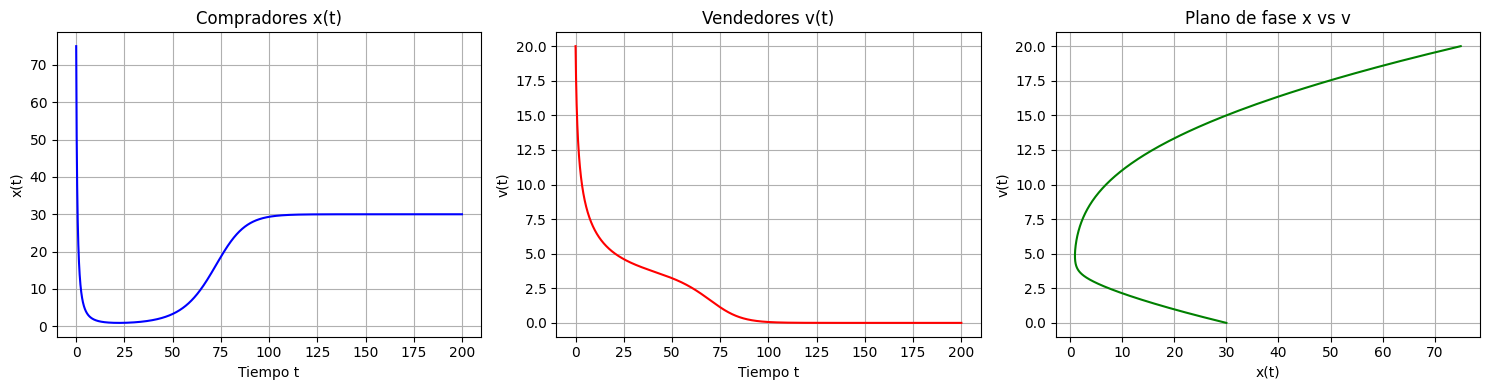

In [ ]:
# (compradores x, vendedores v):
#  x' = x*(a - b*x - m*v),   x(0) = 75
#  v' = v*(c - d*v - n*x),   v(0) = 20
def lotka_a(t, y):
    x, v = y[0], y[1]
    a, b, m_ = 0.3, 0.01, 0.06
    c_, d, n = 0.03, 0.009, 0.0055
    return np.array([x*(a  - b*x - m_*v),
                     v*(c_ - d*v - n*x)])

t, sol = ec.Euler(lotka_a, 0, 200, 0.05, np.array([75.0, 20.0]))
sol = np.array(sol)
x_t, v_t = sol[:, 0], sol[:, 1]

print(f"x(T) = {x_t[-1]:.4f}    v(T) = {v_t[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t, x_t, 'b-'); axes[0].set_title('Compradores x(t)')
axes[0].set_xlabel('Tiempo t'); axes[0].set_ylabel('x(t)'); axes[0].grid(True)
axes[1].plot(t, v_t, 'r-'); axes[1].set_title('Vendedores v(t)')
axes[1].set_xlabel('Tiempo t'); axes[1].set_ylabel('v(t)'); axes[1].grid(True)
axes[2].plot(x_t, v_t, 'g-'); axes[2].set_title('Plano de fase x vs v')
axes[2].set_xlabel('x(t)'); axes[2].set_ylabel('v(t)'); axes[2].grid(True)
plt.tight_layout()
plt.show()

# justificacion: con estos parametros los compradores llegan a su tope
# (x = 30) y los vendedores se extinguen (v -> 0). El enunciado dice que
# ambos coexisten, pero las ecuaciones con estos numeros no lo permiten:
# el punto donde ambas poblaciones podrian quedarse quietas no existe con
# valores positivos. La simulacion confirma que gana la poblacion con
# mejor crecimiento propio.

### b) a=0.26, b=0.2, m=0.06, c=0.06, d=0.01, n=0.015

x(T) = 0.0000    v(T) = 6.0000


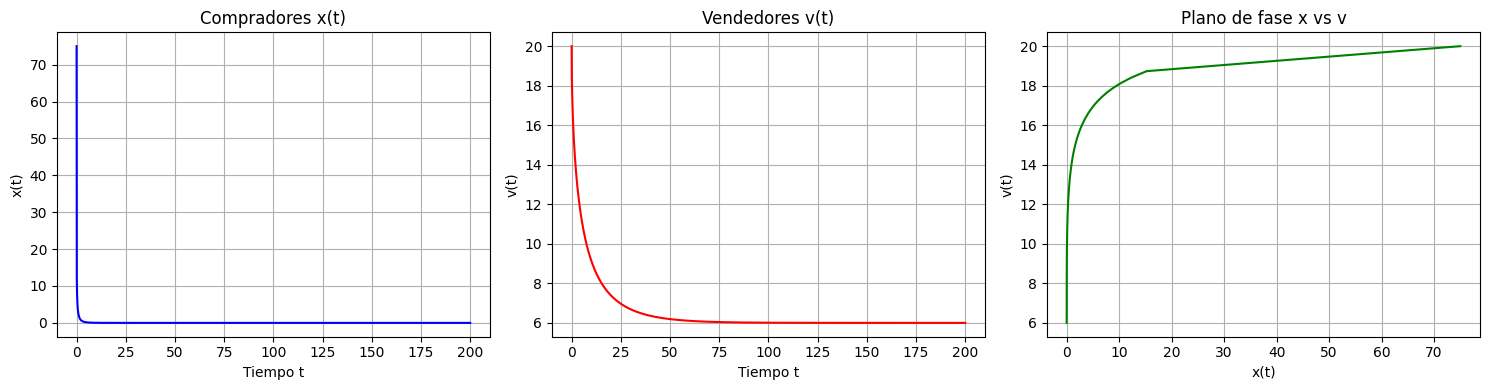

In [ ]:
def lotka_b(t, y):
    x, v = y[0], y[1]
    a, b, m_ = 0.26, 0.2, 0.06
    c_, d, n = 0.06, 0.01, 0.015
    return np.array([x*(a  - b*x - m_*v),
                     v*(c_ - d*v - n*x)])

t, sol = ec.Euler(lotka_b, 0, 200, 0.05, np.array([75.0, 20.0]))
sol = np.array(sol)
x_t, v_t = sol[:, 0], sol[:, 1]

print(f"x(T) = {x_t[-1]:.4f}    v(T) = {v_t[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t, x_t, 'b-'); axes[0].set_title('Compradores x(t)')
axes[0].set_xlabel('Tiempo t'); axes[0].set_ylabel('x(t)'); axes[0].grid(True)
axes[1].plot(t, v_t, 'r-'); axes[1].set_title('Vendedores v(t)')
axes[1].set_xlabel('Tiempo t'); axes[1].set_ylabel('v(t)'); axes[1].grid(True)
axes[2].plot(x_t, v_t, 'g-'); axes[2].set_title('Plano de fase x vs v')
axes[2].set_xlabel('x(t)'); axes[2].set_ylabel('v(t)'); axes[2].grid(True)
plt.tight_layout()
plt.show()

# justificacion: con b = 0.2 los compradores se estorban demasiado entre
# ellos y no logran sostenerse, asi que se extinguen (x -> 0). Sin esa
# competencia encima, los vendedores se estabilizan en v = 6 (su propio
# tope c/d). Basta un solo parametro alto para hundir a una poblacion entera.

### c) a=0.26, b=0.02, m=0.06, c=0.26, d=0.9, n=4.2

x(T) = 13.0000    v(T) = 0.0000


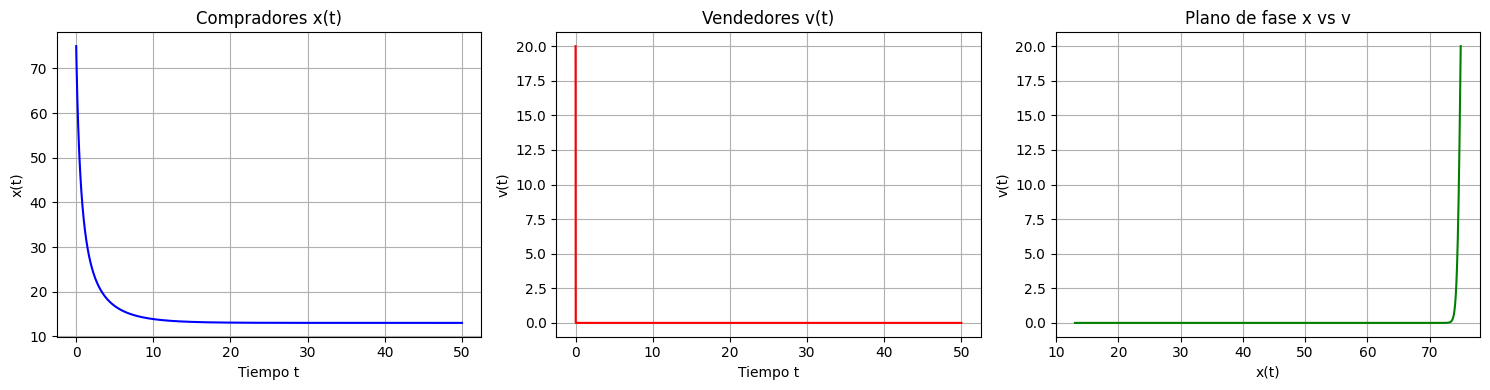

In [ ]:
def lotka_c(t, y):
    x, v = y[0], y[1]
    a, b, m_ = 0.26, 0.02, 0.06
    c_, d, n = 0.26, 0.9, 4.2
    return np.array([x*(a  - b*x - m_*v),
                     v*(c_ - d*v - n*x)])

# h pequeno porque n = 4.2 hace la dinamica muy rapida y Euler con h grande
# genera overflow
t, sol = ec.Euler(lotka_c, 0, 50, 0.001, np.array([75.0, 20.0]))
sol = np.array(sol)
x_t, v_t = sol[:, 0], sol[:, 1]

print(f"x(T) = {x_t[-1]:.4f}    v(T) = {v_t[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t, x_t, 'b-'); axes[0].set_title('Compradores x(t)')
axes[0].set_xlabel('Tiempo t'); axes[0].set_ylabel('x(t)'); axes[0].grid(True)
axes[1].plot(t, v_t, 'r-'); axes[1].set_title('Vendedores v(t)')
axes[1].set_xlabel('Tiempo t'); axes[1].set_ylabel('v(t)'); axes[1].grid(True)
axes[2].plot(x_t, v_t, 'g-'); axes[2].set_title('Plano de fase x vs v')
axes[2].set_xlabel('x(t)'); axes[2].set_ylabel('v(t)'); axes[2].grid(True)
plt.tight_layout()
plt.show()

# justificacion: con n = 4.2 cada comprador frena muchisimo a los vendedores,
# que colapsan en muy pocas unidades de tiempo (v -> 0). Los compradores
# quedan solos y se acomodan en x = 13 (su propio tope a/b). Se usa h = 0.001
# porque con un paso grande Euler no alcanza a seguir la caida tan brusca
# y la simulacion se sale.

### d) a=0.26, b=0.021, m=0.06, c=0.06, d=0.01, n=0.01

x(T) = 0.0000    v(T) = 6.0000


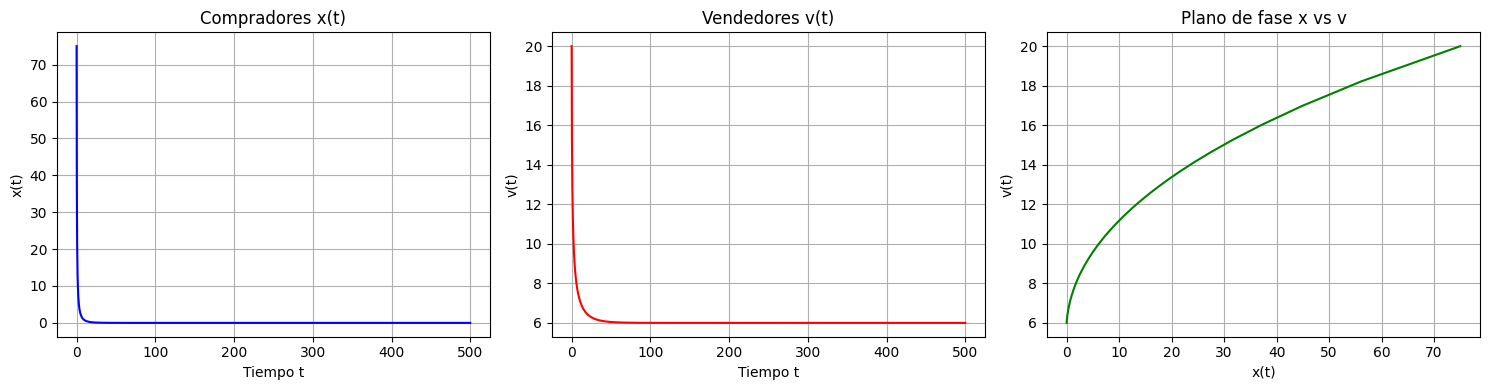

In [ ]:
def lotka_d(t, y):
    x, v = y[0], y[1]
    a, b, m_ = 0.26, 0.021, 0.06
    c_, d, n = 0.06, 0.01, 0.01
    return np.array([x*(a  - b*x - m_*v),
                     v*(c_ - d*v - n*x)])

t, sol = ec.Euler(lotka_d, 0, 500, 0.1, np.array([75.0, 20.0]))
sol = np.array(sol)
x_t, v_t = sol[:, 0], sol[:, 1]

print(f"x(T) = {x_t[-1]:.4f}    v(T) = {v_t[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t, x_t, 'b-'); axes[0].set_title('Compradores x(t)')
axes[0].set_xlabel('Tiempo t'); axes[0].set_ylabel('x(t)'); axes[0].grid(True)
axes[1].plot(t, v_t, 'r-'); axes[1].set_title('Vendedores v(t)')
axes[1].set_xlabel('Tiempo t'); axes[1].set_ylabel('v(t)'); axes[1].grid(True)
axes[2].plot(x_t, v_t, 'g-'); axes[2].set_title('Plano de fase x vs v')
axes[2].set_xlabel('x(t)'); axes[2].set_ylabel('v(t)'); axes[2].grid(True)
plt.tight_layout()
plt.show()

# justificacion: existe un punto donde ambas poblaciones podrian quedarse
# quietas (x ~ 2.56, v ~ 3.44), pero ese punto es inestable: como una bola
# en la cima de un cerro, cualquier desvio empuja al sistema hacia un lado.
# Con las condiciones iniciales (75, 20) la trayectoria termina en (0, 6):
# los compradores se extinguen y ganan los vendedores. Las condiciones
# iniciales deciden hacia que final cae el sistema.